# Employee Attrition Prediction using Machine Learning

**CSE422: Artificial Intelligence — Lab Project**  
**Authors:** Irfan Rahman (24301330) and Zarifah Morshed Nuren (24301499)  
**Group 4 | Section 4 | Summer 2026**

## 1. Introduction

Employee attrition can create significant financial and operational challenges for organizations. This project applies introductory machine learning techniques to analyze HR data and predict whether an employee is likely to stay or leave.

- **Target feature:** `Attrition`
- **Class 0:** Stayed
- **Class 1:** Left

The notebook covers dataset exploration, preprocessing, supervised classification, neural networks, unsupervised K-Means clustering, and model evaluation.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

## 2. Dataset Description

The dataset contains employee demographic, job-related, compensation, satisfaction, and tenure information.

For the GitHub repository, the recommended dataset location is:

`data/employee_attrition.csv`

The loading cell below also accepts the original filename `4.csv` as a fallback.


In [2]:
from pathlib import Path

# Recommended repository structure:
# employee-attrition-prediction/
# ├── data/employee_attrition.csv
# └── notebook/employee_attrition_prediction.ipynb
#
# The fallbacks also make the notebook convenient to run from the repository
# root, from the notebook directory, or after manually uploading the dataset.

candidate_paths = [
    Path("../data/employee_attrition.csv"),
    Path("data/employee_attrition.csv"),
    Path("employee_attrition.csv"),
    Path("../data/4.csv"),
    Path("data/4.csv"),
    Path("4.csv"),
]

file_path = next((path for path in candidate_paths if path.exists()), None)

if file_path is None:
    raise FileNotFoundError(
        "Dataset not found. Place it at 'data/employee_attrition.csv' "
        "(recommended) or upload 'employee_attrition.csv'/'4.csv' beside the notebook."
    )

dataset = pd.read_csv(file_path)
print(f"Loaded dataset from: {file_path}")
dataset.head()


,id,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,0,36,Travel_Frequently,599,Research & Development,24,3,Medical,1,4,Male,42,3,1,Laboratory Technician,4,Married,2596,5099,1,Y,Yes,13,3,2,80,1,10,2,3,10,0,7,8,0
1,1,35,Travel_Rarely,921,Sales,8,3,Other,1,1,Male,46,3,1,Sales Representative,1,Married,2899,10778,1,Y,No,17,3,4,80,1,4,3,3,4,2,0,3,0
2,2,32,Travel_Rarely,718,Sales,26,3,Marketing,1,3,Male,80,3,2,Sales Executive,4,Divorced,4627,16495,0,Y,No,17,3,4,80,2,4,3,3,3,2,1,2,0
3,3,38,Travel_Rarely,1488,Research & Development,2,3,Medical,1,3,Female,40,3,2,Healthcare Representative,1,Married,5347,13384,3,Y,No,14,3,3,80,0,15,1,1,6,0,0,2,0
4,4,50,Travel_Rarely,1017,Research & Development,5,4,Medical,1,2,Female,37,3,5,Manager,1,Single,19033,19805,1,Y,Yes,13,3,3,80,0,31,0,3,31,14,4,10,1


In [3]:
print('Shape of the dataset is {}. This dataset contains {} rows and {} columns.'
      .format(dataset.shape, dataset.shape[0], dataset.shape[1]))

Shape of the dataset is (1677, 35). This dataset contains 1677 rows and 35 columns.


In [4]:
# Selecting numerical features
numerical_data = dataset.select_dtypes(include='number')
numerical_features = numerical_data.columns.tolist()

print(f'There are {len(numerical_features)} numerical features:\n')
print(numerical_features)

# Selecting categorical features
categorical_data = dataset.select_dtypes(include='object')
categorical_features = categorical_data.columns.tolist()

print(f'There are {len(categorical_features)} categorical features:\n')
print(categorical_features)

There are 27 numerical features:

['id', 'Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition']
There are 8 categorical features:

['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


## 3. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is used to examine data quality, class imbalance, feature distributions, associations with attrition, and multicollinearity before preprocessing and model training.


In [5]:
dataset.isnull().sum()

,0
id,0
Age,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EnvironmentSatisfaction,0


In [6]:
print('Number of duplicate rows:', dataset.duplicated().sum())

Number of duplicate rows: 0


In [7]:
dataset.nunique()

,0
id,1677
Age,43
BusinessTravel,3
DailyRate,625
Department,3
DistanceFromHome,29
Education,6
EducationField,6
EmployeeCount,1
EnvironmentSatisfaction,4


### 3.1 Class Distribution and Imbalance — Fig. 3.1

The distribution of the target variable is examined to determine whether the two attrition classes are balanced.


In [8]:
class_counts = dataset.groupby('Attrition').size()

total = len(dataset)
outcome = [0, 1]
count = [class_counts[v] for v in outcome]
percentage = [(c/total)*100 for c in count]

imbalance_df = pd.DataFrame(list(zip(outcome, count, percentage)),
                             columns=['Attrition', 'count', 'percentage'])
imbalance_df

,Attrition,count,percentage
0,0,1477,88.073942
1,1,200,11.926058


/tmp/ipykernel_1465/855616757.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imbalance_df, x='Attrition', y='percentage', palette='coolwarm')


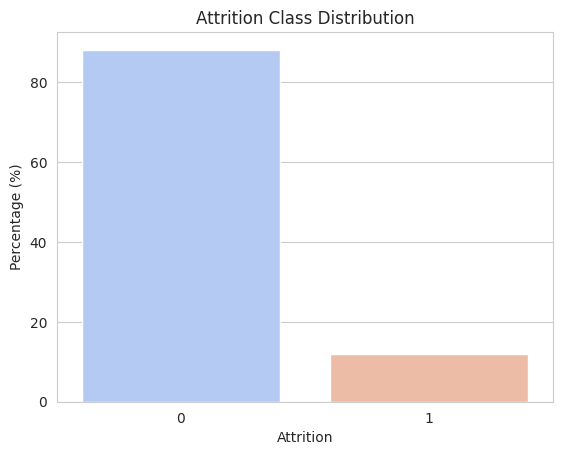

In [9]:
sns.barplot(data=imbalance_df, x='Attrition', y='percentage', palette='coolwarm')
plt.title('Attrition Class Distribution')
plt.ylabel('Percentage (%)')

plt.show()

### 3.2 Feature Skewness and Outliers — Fig. 3.2

Selected numerical features are inspected for skewness and visible outliers. These observations later motivate the choice of `RobustScaler`.


In [10]:
numerical_data[['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'YearsSinceLastPromotion', 'Attrition']].skew()

,0
MonthlyIncome,1.551410
TotalWorkingYears,1.145234
YearsAtCompany,1.738288
YearsSinceLastPromotion,2.080754
Attrition,2.351659


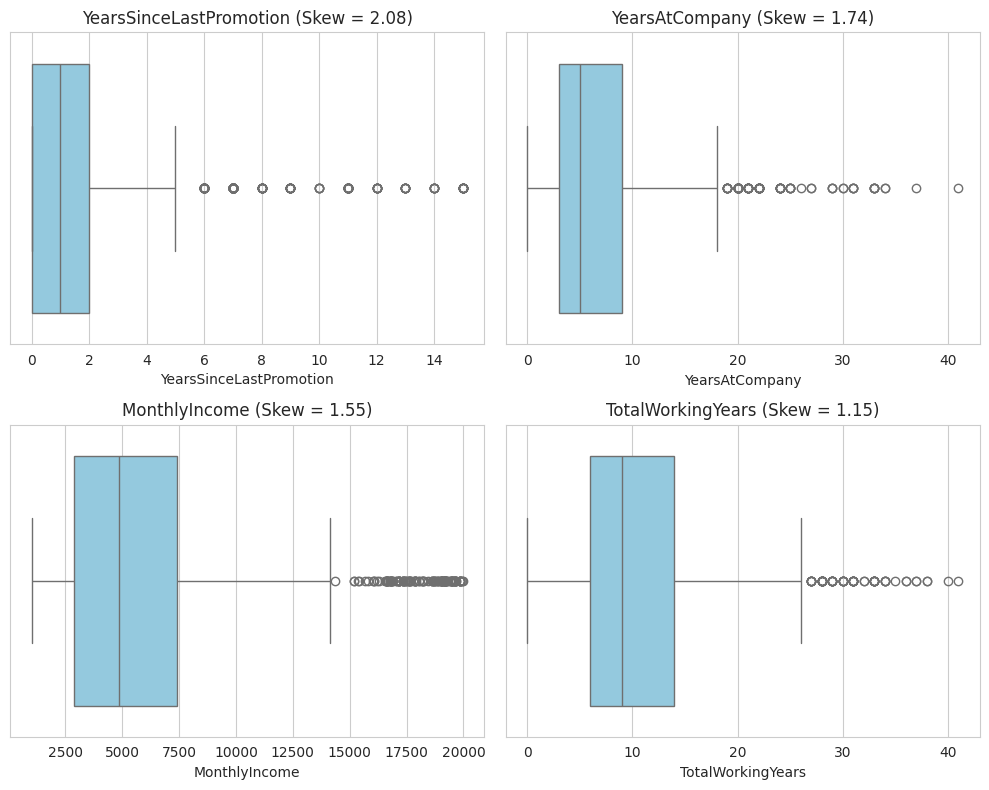

In [11]:
features_to_plot = ['YearsSinceLastPromotion', 'YearsAtCompany', 'MonthlyIncome', 'TotalWorkingYears']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, col in zip(axes, features_to_plot):
    sns.boxplot(x=dataset[col], color='skyblue', ax=ax)
    ax.set_title(f'{col} (Skew = {dataset[col].skew():.2f})')
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

### 3.3 Prepare Numerical Features for Correlation Analysis

Constant numerical columns are removed from the temporary EDA dataframe so that they do not produce undefined (`NaN`) correlation values.


In [12]:
numerical_data = numerical_data.drop(columns=['EmployeeCount', 'StandardHours'], errors='ignore')

### 3.4 Pearson Correlation with Attrition — Fig. 3.3

Pearson correlation is used to examine the linear relationship between numerical features and the `Attrition` target.


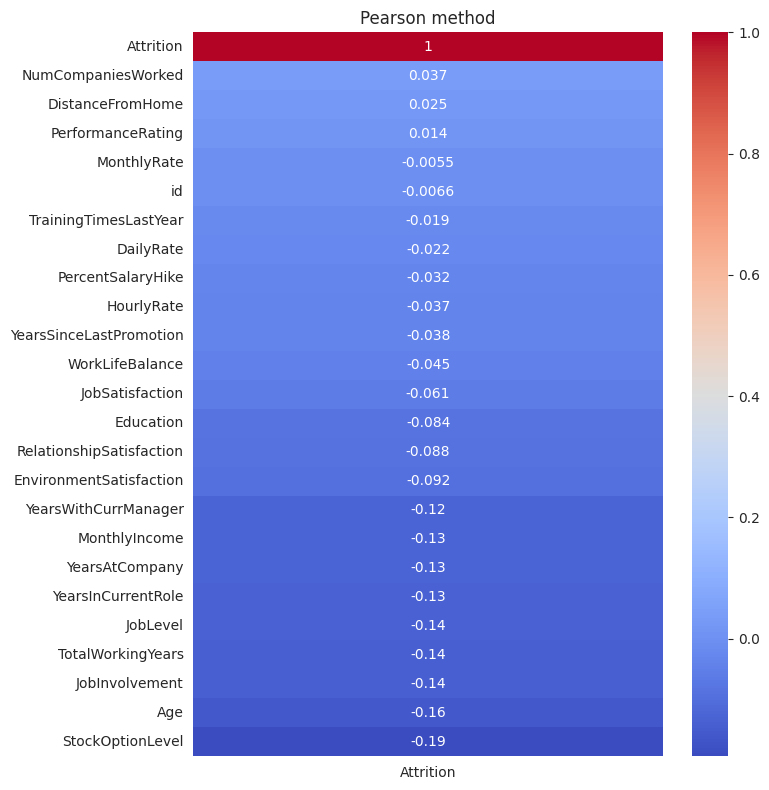

In [13]:
plt.figure(figsize=(8, 8))

# Calculate Pearson correlation sorted by Attrition
corr1 = numerical_data.corr(method='pearson')[['Attrition']].sort_values(by='Attrition', ascending=False)

# Plot the heatmap
plt.title('Pearson method')
sns.heatmap(corr1, annot=True, cmap='coolwarm')

plt.tight_layout()
plt.show()

### 3.5 Attrition Rates Across Key Categorical Features — Fig. 3.4

Cross-tabulations are used to compare attrition rates across `OverTime`, `MaritalStatus`, and `JobRole`.


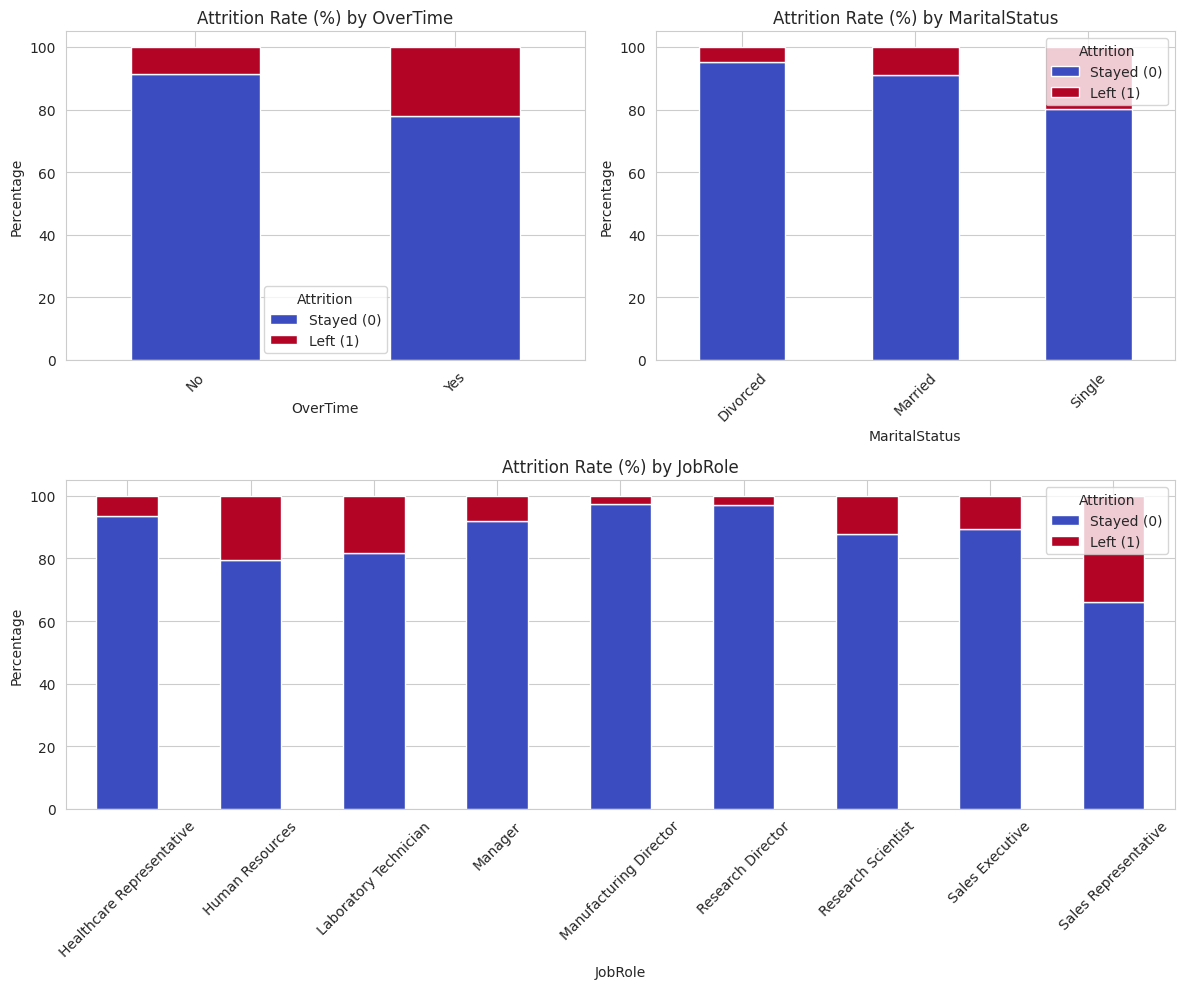

In [14]:
fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(2, 2)

# Plot 1: OverTime (Top Left)
ax1 = fig.add_subplot(gs[0, 0])
ct1 = pd.crosstab(dataset['OverTime'], dataset['Attrition'], normalize='index') * 100
ct1.plot(kind='bar', stacked=True, colormap='coolwarm', ax=ax1)
ax1.set_title('Attrition Rate (%) by OverTime')
ax1.set_ylabel('Percentage')
ax1.legend(title='Attrition', labels=['Stayed (0)', 'Left (1)'])
ax1.tick_params(axis='x', rotation=45)

# Plot 2: MaritalStatus (Top Right)
ax2 = fig.add_subplot(gs[0, 1])
ct2 = pd.crosstab(dataset['MaritalStatus'], dataset['Attrition'], normalize='index') * 100
ct2.plot(kind='bar', stacked=True, colormap='coolwarm', ax=ax2)
ax2.set_title('Attrition Rate (%) by MaritalStatus')
ax2.set_ylabel('Percentage')
ax2.legend(title='Attrition', labels=['Stayed (0)', 'Left (1)'])
ax2.tick_params(axis='x', rotation=45)

# Plot 3: JobRole (Bottom, spanning both columns)
ax3 = fig.add_subplot(gs[1, :])
ct3 = pd.crosstab(dataset['JobRole'], dataset['Attrition'], normalize='index') * 100
ct3.plot(kind='bar', stacked=True, colormap='coolwarm', ax=ax3)
ax3.set_title('Attrition Rate (%) by JobRole')
ax3.set_ylabel('Percentage')
ax3.legend(title='Attrition', labels=['Stayed (0)', 'Left (1)'])
ax3.tick_params(axis='x', rotation=45)

# Clean up layout and save to PDF
plt.tight_layout()
plt.show()

### 3.6 Cramér's V for Categorical Features — Fig. 3.5

Cramér's V is calculated to measure the strength of association between categorical features and `Attrition`.


JobRole           0.216590
MaritalStatus     0.181350
OverTime          0.171806
BusinessTravel    0.116391
EducationField    0.067282
Department        0.055326
Gender            0.040524
dtype: float64


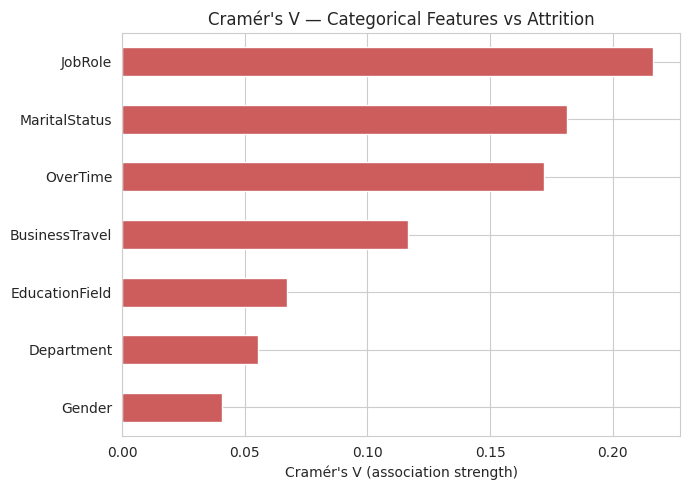

In [15]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

cramers_results = {}
for col in categorical_features:
    if col != 'Over18':   # skip constant column, see note below
        cramers_results[col] = cramers_v(dataset[col], dataset['Attrition'])

cramers_df = pd.Series(cramers_results).sort_values(ascending=False)
print(cramers_df)

plt.figure(figsize=(7, 5))
cramers_df.plot(kind='barh', color='indianred')
plt.title("Cramér's V — Categorical Features vs Attrition")
plt.xlabel("Cramér's V (association strength)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 3.7 Multicollinearity Analysis — Fig. 3.6

A focused correlation heatmap is used to inspect highly correlated tenure and compensation features. The strong correlation between `JobLevel` and `MonthlyIncome` is later addressed during feature selection.


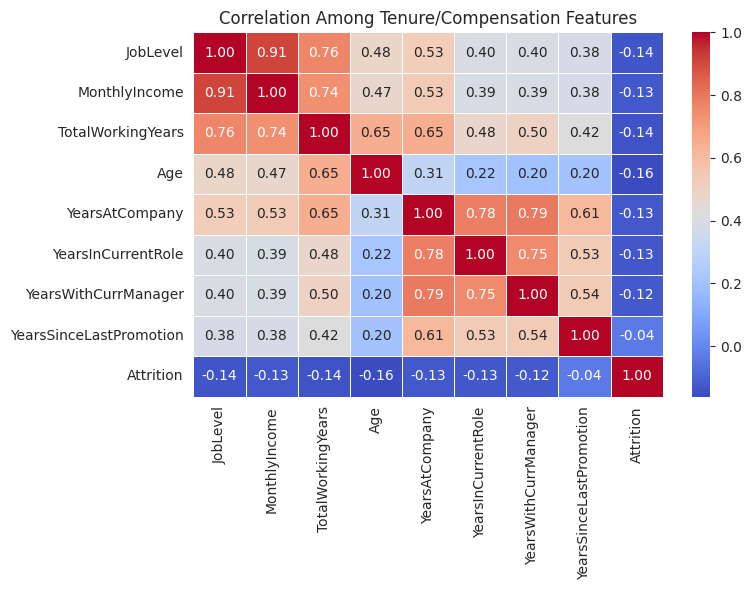

In [16]:
cluster_cols = ['JobLevel', 'MonthlyIncome', 'TotalWorkingYears', 'Age',
                 'YearsAtCompany', 'YearsInCurrentRole', 'YearsWithCurrManager',
                 'YearsSinceLastPromotion', 'Attrition']

cluster_corr = dataset[cluster_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(cluster_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.4)
plt.title('Correlation Among Tenure/Compensation Features')
plt.tight_layout()
plt.show()

## 4. Dataset Preprocessing

The preprocessing steps below follow directly from the issues identified during EDA.


### 4.1 Check Missing and Duplicate Values

The dataset is rechecked before transformation. Since no missing or duplicate records are present, no imputation or row removal is required.


In [17]:
print("Missing values per column:\n", dataset.isnull().sum().sum())
print("Duplicate rows:", dataset.duplicated().sum())
# Confirmed clean in EDA — 0 and 0. No imputation/row-dropping needed.

Missing values per column:
 0
Duplicate rows: 0


### 4.2 Remove Non-Informative Features

The unique identifier `id` and the zero-variance columns `EmployeeCount`, `StandardHours`, and `Over18` are removed because they do not provide useful predictive information.


In [18]:
# Drop zero-variance columns (EmployeeCount, StandardHours, Over18) and the id column
dataset = dataset.drop(columns=['id', 'EmployeeCount', 'StandardHours', 'Over18'], errors='ignore')
print("Shape after dropping non-informative columns:", dataset.shape)

Shape after dropping non-informative columns: (1677, 31)


### 4.3 Encode Categorical Features

Categorical features are converted to numerical form using:

- Binary mapping for `OverTime` and `Gender`
- Ordinal mapping for `BusinessTravel`
- One-hot encoding for nominal categorical features


In [19]:
# 1. Binary features -> map to 0/1
dataset['OverTime'] = dataset['OverTime'].map({'No': 0, 'Yes': 1})
dataset['Gender'] = dataset['Gender'].map({'Female': 0, 'Male': 1})

# 2. Ordinal feature -> BusinessTravel has a natural ranking
dataset['BusinessTravel'] = dataset['BusinessTravel'].map({
    'Non-Travel': 0,
    'Travel_Rarely': 1,
    'Travel_Frequently': 2
})

# 3. Nominal features (no inherent order) -> One-Hot Encoding
nominal_cols = ['Department', 'EducationField', 'JobRole', 'MaritalStatus']
dataset = pd.get_dummies(dataset, columns=nominal_cols, drop_first=True)

print(dataset.shape)
dataset.head()

(1677, 44)


,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,36,2,599,24,3,4,1,42,3,1,4,2596,5099,1,1,13,3,2,1,10,2,3,10,0,7,8,0,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False
1,35,1,921,8,3,1,1,46,3,1,1,2899,10778,1,0,17,3,4,1,4,3,3,4,2,0,3,0,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,True,False
2,32,1,718,26,3,3,1,80,3,2,4,4627,16495,0,0,17,3,4,2,4,3,3,3,2,1,2,0,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False
3,38,1,1488,2,3,3,0,40,3,2,1,5347,13384,3,0,14,3,3,0,15,1,1,6,0,0,2,0,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False
4,50,1,1017,5,4,2,0,37,3,5,1,19033,19805,1,1,13,3,3,0,31,0,3,31,14,4,10,1,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True


### 4.4 Feature Selection for Severe Multicollinearity

EDA showed a strong correlation between `JobLevel` and `MonthlyIncome`. `JobLevel` is removed while `MonthlyIncome` is retained as the more fine-grained compensation feature.


In [20]:
# EDA found JobLevel <-> MonthlyIncome severely collinear (r = 0.91)
# Keep MonthlyIncome (finer-grained, continuous); drop JobLevel (redundant, coarser)
dataset = dataset.drop(columns=['JobLevel'], errors='ignore')
print("Shape after removing multicollinear feature:", dataset.shape)

Shape after removing multicollinear feature: (1677, 43)


### 4.5 Separate Features and Target, Then Split the Data

The target is separated from the predictors before an 80/20 stratified train-test split. Stratification preserves the original class distribution in both partitions.


In [21]:
from sklearn.model_selection import train_test_split

X = dataset.drop(columns=['Attrition'])
y = dataset['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # preserves the 88/12 imbalance ratio in both train and test
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))
print("Test class balance:\n", y_test.value_counts(normalize=True))

Train shape: (1341, 42)  Test shape: (336, 42)
Train class balance:
 Attrition
0    0.880686
1    0.119314
Name: proportion, dtype: float64
Test class balance:
 Attrition
0    0.880952
1    0.119048
Name: proportion, dtype: float64


### 4.6 Feature Scaling with RobustScaler

`RobustScaler` is fitted **only on the training data** and then applied to both the training and test sets. It is used because the EDA identified skewed numerical features and visible outliers.


In [22]:
from sklearn.preprocessing import RobustScaler

# RobustScaler chosen over StandardScaler/MinMaxScaler because EDA (Fig 3.2)
# identified significant outliers in MonthlyIncome, TotalWorkingYears,
# YearsAtCompany, and YearsSinceLastPromotion. RobustScaler uses median and
# IQR instead of mean/std, making it far less sensitive to those outliers.

scaler = RobustScaler()

# Fit ONLY on training data — prevents test-set information from leaking
# into the scaling parameters (a classic and easy-to-make mistake)
scaler.fit(X_train)

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

X_train_scaled.head()

,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
414,1.636364,0.0,0.928125,0.0,0.5,0.0,-1.0,0.18750,0.0,-1.0,1.526938,0.756767,0.333333,0.0,0.2,0.0,-0.5,-1.0,2.125,0.0,0.0,1.500000,1.4,2.0,0.8,-1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
91,-0.545455,0.0,-1.157812,1.3,0.5,0.0,-1.0,0.65625,0.0,0.0,-0.204336,-0.204923,0.000000,0.0,-0.6,0.0,0.5,0.0,-0.500,-1.0,-1.0,0.000000,0.0,-0.5,-0.2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1650,1.363636,0.0,0.528125,-0.6,0.0,0.0,0.0,-0.90625,0.0,-0.5,-0.435830,-0.980291,0.333333,0.0,2.0,1.0,-1.0,0.0,-0.125,2.0,0.0,0.000000,0.2,-0.5,-0.4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
450,0.363636,0.0,-0.710938,0.0,0.5,-1.0,0.0,-0.28125,0.0,0.5,-0.335304,0.605746,2.000000,1.0,1.6,1.0,0.5,0.0,-0.250,0.0,0.0,-0.666667,-0.6,-0.5,-0.6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1541,0.636364,0.0,0.868750,0.1,0.5,0.0,-1.0,-0.71875,-1.0,-1.0,0.132939,0.189251,2.666667,0.0,-0.6,0.0,0.5,-1.0,1.375,1.0,-1.0,0.500000,0.8,-0.5,0.8,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


## 5. Model Training

Four approaches are trained for comparison: a feedforward Neural Network, Logistic Regression, Gaussian Naive Bayes, and K-Means clustering.


### 5.1 Neural Network

A feedforward neural network with one hidden layer is trained for binary classification using ReLU activation in the hidden layer and sigmoid activation in the output layer.

> Neural-network training is stochastic, so exact results may vary slightly between runs.


In [23]:
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam


In [24]:
# Create model
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile model
model.compile(
    optimizer=Adam(0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=10,
    batch_size=32
)


Epoch 1/10


42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7539 - loss: 0.5264
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8807 - loss: 0.3597
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8807 - loss: 0.3265
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8822 - loss: 0.3029
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8881 - loss: 0.2855
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8934 - loss: 0.2721
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8986 - loss: 0.2620
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8986 - loss: 0.2542
Epoch 9/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9023 - loss: 0.2464
Epoch 10/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9083 - loss: 0.2387


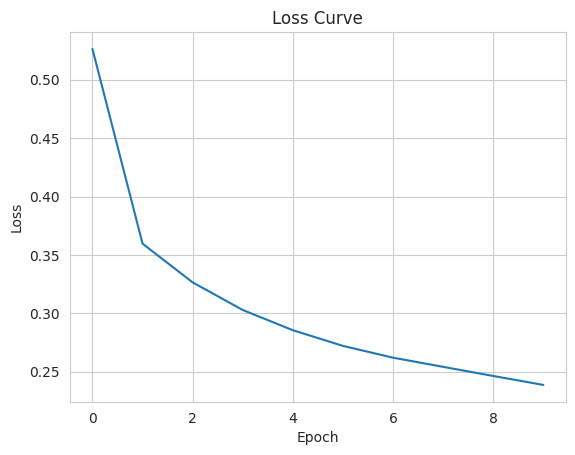

Testing Accuracy: 88.39%


In [25]:
# Plot loss curve
plt.plot(history.history['loss'])
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.savefig('Loss_Curve.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Print test accuracy
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Testing Accuracy: {round(test_accuracy * 100, 2)}%")


### 5.2 Logistic Regression

Logistic Regression is trained as a simple and interpretable supervised baseline for the binary classification task.


In [26]:
from sklearn.linear_model import LogisticRegression

# Create and train model
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

# Quick sanity-check accuracy (full evaluation deferred to Section VI)
train_acc = log_reg.score(X_train_scaled, y_train)
test_acc = log_reg.score(X_test_scaled, y_test)

print(f"Training Accuracy: {round(train_acc * 100, 2)}%")
print(f"Testing Accuracy: {round(test_acc * 100, 2)}%")

Training Accuracy: 89.63%
Testing Accuracy: 88.1%


### 5.3 Gaussian Naive Bayes

Gaussian Naive Bayes is trained as a probabilistic supervised classifier for comparison with the Neural Network and Logistic Regression.


In [27]:
from sklearn.naive_bayes import GaussianNB

# Create the model
gnb_model = GaussianNB()

# Train the model
gnb_model.fit(X_train_scaled, y_train)

# Training and testing accuracy
gnb_train_accuracy = gnb_model.score(X_train_scaled, y_train)
gnb_test_accuracy = gnb_model.score(X_test_scaled, y_test)

print(f"Training Accuracy: {round(gnb_train_accuracy * 100, 2)}%")
print(f"Testing Accuracy: {round(gnb_test_accuracy * 100, 2)}%")

Training Accuracy: 71.81%
Testing Accuracy: 68.15%


### 5.4 K-Means Clustering (Unsupervised)

K-Means is used to treat the task from an unsupervised perspective. The algorithm is trained without using the `Attrition` labels.


The model is fitted on the scaled training features with `k = 2`. Test samples are then assigned to the learned clusters.

For evaluation only, the cluster associated with the higher attrition rate is identified **using the training labels** and that mapping is applied to the test clusters. This avoids using test labels to define the cluster-to-class mapping.


In [28]:
from sklearn.cluster import KMeans

k = 2

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)

# Training clusters are used only to learn the cluster-to-class mapping.
train_clusters = kmeans.labels_

# Test clusters are used for evaluation.
clusters = kmeans.predict(X_test_scaled)

print("Cluster Distribution:")
print(pd.Series(clusters).value_counts())


Cluster Distribution:
1    256
0     80
Name: count, dtype: int64


In [29]:
pd.crosstab(
    y_test,
    clusters,
    rownames=["Actual Attrition"],
    colnames=["Cluster"]
)

# This table is shown only to inspect how the learned clusters align with
# the true test labels. It is NOT used to decide which cluster represents
# the "Left" class.


Cluster,0,1
Actual Attrition,,
0,73,223
1,7,33


## 6. Model Evaluation

The models are compared using confusion matrices, classification reports, ROC curves, AUC, accuracy, precision, recall, and F1-score. Because the target is imbalanced, minority-class metrics are especially important.


In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score

### 6.1 Confusion Matrices

Confusion matrices show the number of correct and incorrect predictions for the `Stayed` and `Left` classes.


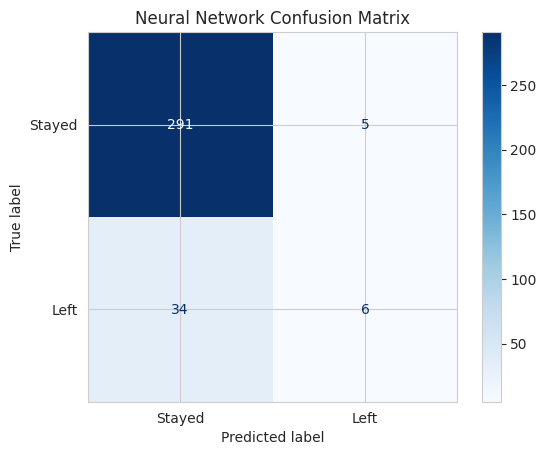

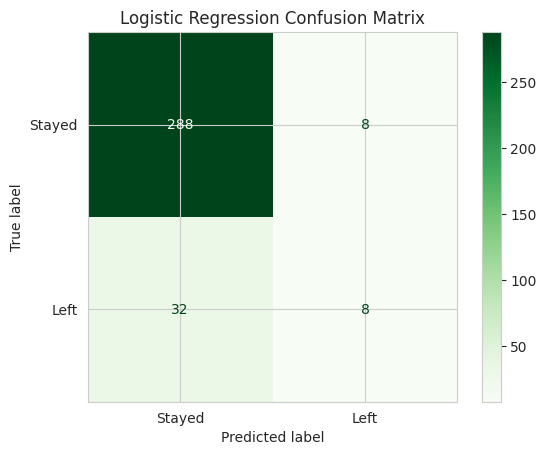

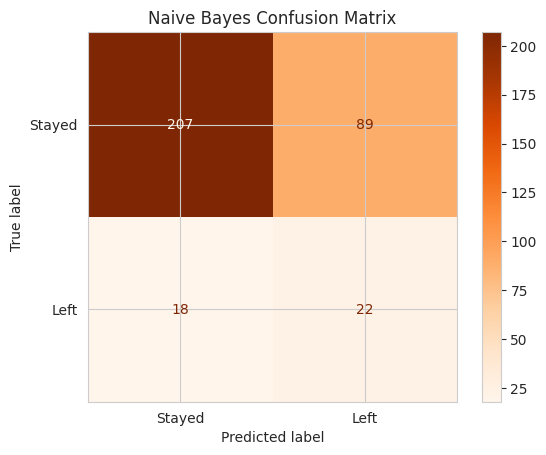

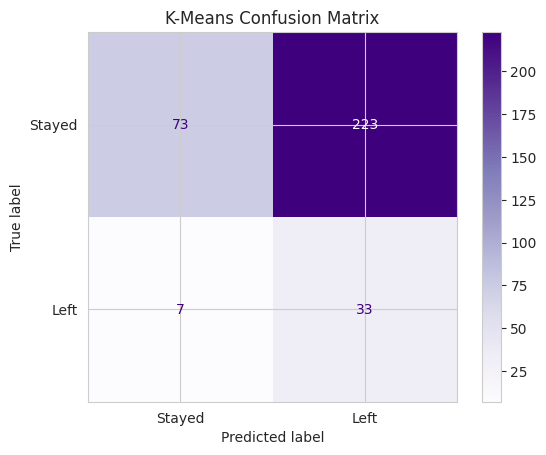

In [31]:
# Get predictions from each supervised model
y_pred_nn = (model.predict(X_test_scaled, verbose=0) > 0.5).astype(int).ravel()
y_pred_log = log_reg.predict(X_test_scaled)
y_pred_nb = gnb_model.predict(X_test_scaled)

# Neural Network
cm_nn = confusion_matrix(y_test, y_pred_nn)
ConfusionMatrixDisplay(cm_nn, display_labels=['Stayed', 'Left']).plot(cmap="Blues")
plt.title("Neural Network Confusion Matrix")
plt.savefig('cm_nn.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Logistic Regression
cm_log = confusion_matrix(y_test, y_pred_log)
ConfusionMatrixDisplay(cm_log, display_labels=['Stayed', 'Left']).plot(cmap="Greens")
plt.title("Logistic Regression Confusion Matrix")
plt.savefig('cm_log.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Gaussian Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)
ConfusionMatrixDisplay(cm_nb, display_labels=['Stayed', 'Left']).plot(cmap="Oranges")
plt.title("Gaussian Naive Bayes Confusion Matrix")
plt.savefig('cm_nb.pdf', format='pdf', bbox_inches='tight')
plt.show()

# K-Means cluster-to-class mapping:
# Learn which cluster has the higher attrition rate from TRAINING data only.
cluster_attrition_rate = y_train.groupby(train_clusters).mean()
left_cluster = cluster_attrition_rate.idxmax()

# Apply the learned mapping to the TEST clusters.
y_pred_kmeans = (clusters == left_cluster).astype(int)

cm_kmeans = confusion_matrix(y_test, y_pred_kmeans)
ConfusionMatrixDisplay(cm_kmeans, display_labels=['Stayed', 'Left']).plot(cmap="Purples")
plt.title("K-Means Confusion Matrix")
plt.savefig('cm_kmeans.pdf', format='pdf', bbox_inches='tight')
plt.show()


### 6.2 Classification Reports

Precision, recall, and F1-score are reported for each class to provide a more informative comparison than accuracy alone.


In [32]:
print("Neural Network:")
print(classification_report(y_test, y_pred_nn, target_names=['Stayed', 'Left']))

print("Logistic Regression:")
print(classification_report(y_test, y_pred_log, target_names=['Stayed', 'Left']))

print("Gaussian Naive Bayes:")
print(classification_report(y_test, y_pred_nb, target_names=['Stayed', 'Left']))

print("K-Means:")
print(classification_report(y_test, y_pred_kmeans, target_names=['Stayed', 'Left']))


Neural Network:
              precision    recall  f1-score   support

      Stayed       0.90      0.98      0.94       296
        Left       0.55      0.15      0.24        40

    accuracy                           0.88       336
   macro avg       0.72      0.57      0.59       336
weighted avg       0.85      0.88      0.85       336

Logistic Regression:
              precision    recall  f1-score   support

      Stayed       0.90      0.97      0.94       296
        Left       0.50      0.20      0.29        40

    accuracy                           0.88       336
   macro avg       0.70      0.59      0.61       336
weighted avg       0.85      0.88      0.86       336

Naive Bayes:
              precision    recall  f1-score   support

      Stayed       0.92      0.70      0.79       296
        Left       0.20      0.55      0.29        40

    accuracy                           0.68       336
   macro avg       0.56      0.62      0.54       336
weighted avg       0.83 

### 6.3 ROC Curves and AUC

ROC curves provide a threshold-independent comparison of the models' ability to distinguish between employees who stayed and employees who left.


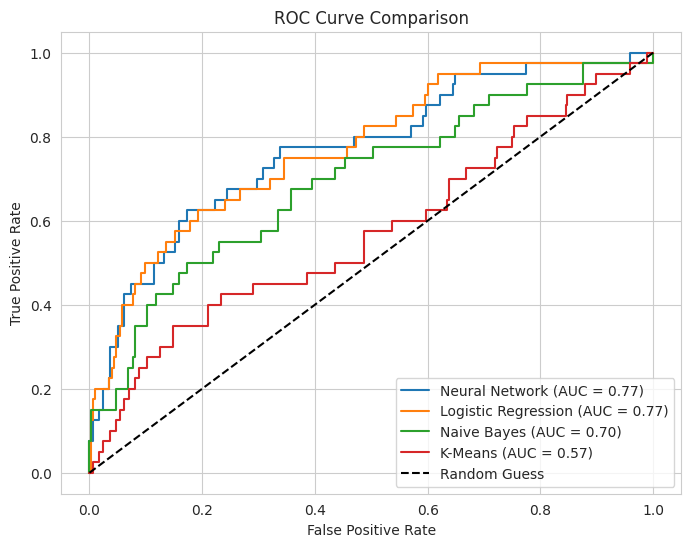

In [33]:
plt.figure(figsize=(8, 6))

# Neural Network
y_probs_nn = model.predict(X_test_scaled, verbose=0).ravel()
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_probs_nn)
auc_nn = auc(fpr_nn, tpr_nn)
plt.plot(fpr_nn, tpr_nn, label=f"Neural Network (AUC = {auc_nn:.2f})")

# Logistic Regression
y_probs_log = log_reg.predict_proba(X_test_scaled)[:, 1]
fpr_log, tpr_log, _ = roc_curve(y_test, y_probs_log)
auc_log = auc(fpr_log, tpr_log)
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.2f})")

# Gaussian Naive Bayes
y_probs_nb = gnb_model.predict_proba(X_test_scaled)[:, 1]
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_probs_nb)
auc_nb = auc(fpr_nb, tpr_nb)
plt.plot(fpr_nb, tpr_nb, label=f"Gaussian Naive Bayes (AUC = {auc_nb:.2f})")

# K-Means
distances = kmeans.transform(X_test_scaled)
other_cluster = 1 - left_cluster
y_score_kmeans = distances[:, other_cluster] - distances[:, left_cluster]
fpr_kmeans, tpr_kmeans, _ = roc_curve(y_test, y_score_kmeans)
auc_kmeans = auc(fpr_kmeans, tpr_kmeans)
plt.plot(fpr_kmeans, tpr_kmeans, label=f"K-Means (AUC = {auc_kmeans:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.savefig('roc_comparison.pdf', format='pdf', bbox_inches='tight')
plt.show()


### 6.4 Summary Comparison

The final table summarizes the main evaluation metrics for all four approaches.


In [34]:
results_df = pd.DataFrame({
    'Model': ['Neural Network', 'Logistic Regression', 'Gaussian Naive Bayes', 'K-Means'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_nn),
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_kmeans)
    ],
    'Precision': [
        precision_score(y_test, y_pred_nn),
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_kmeans)
    ],
    'Recall': [
        recall_score(y_test, y_pred_nn),
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_kmeans)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_nn),
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_kmeans)
    ],
    'AUC': [auc_nn, auc_log, auc_nb, auc_kmeans]
})

print(results_df.round(3))


                 Model  Accuracy  Precision  Recall  F1-Score    AUC
0       Neural Network     0.884      0.545   0.150     0.235  0.770
1  Logistic Regression     0.881      0.500   0.200     0.286  0.772
2          Naive Bayes     0.682      0.198   0.550     0.291  0.697
3              K-Means     0.315      0.129   0.825     0.223  0.573


## 7. Conclusion

The project demonstrates why multiple evaluation metrics are necessary for an imbalanced classification problem.

- Logistic Regression and the Neural Network provide strong overall classification performance.
- Gaussian Naive Bayes identifies a larger proportion of employees in the minority `Left` class, but with more false positives.
- K-Means achieves high recall for the `Left` class but low precision and weak overall discrimination, showing that the unsupervised clusters do not align cleanly with the true attrition labels.

Therefore, the most appropriate model depends on the practical objective: overall discrimination and accuracy versus stronger detection of employees who may leave.
